# Pipeline de Processamento e Recuperação da Imagem 'Letters-noisy.png'

**Objetivo:** Este notebook implementa um pipeline completo para limpar a imagem `Letters-noisy.png`, que sofre de dois tipos de ruído: periódico (linhas e padrões repetitivos) e sal e pimenta (pontos brancos e pretos aleatórios).

O processo está dividido nos seguintes passos:
1. **Análise no Domínio da Frequência:** Usamos a Transformada de Fourier para visualizar o ruído periódico como picos de alta energia no espectro.
2. **Deteção Automática de Picos (2 Passagens):** Identificamos os picos de ruído de forma automática, primeiro os mais intensos e depois os secundários.
3. **Criação de Filtros Notch:** Geramos filtros para "bloquear" (atenuar) as frequências correspondentes aos picos de ruído detetados.
4. **Filtragem de Ruído Periódico:** Aplicamos os filtros e reconstruímos a imagem, agora sem o ruído periódico.
5. **Remoção de Ruído Sal e Pimenta:** Usamos um filtro de mediana para eliminar os pontos aleatórios restantes.
6. **Análise e Segmentação:** Analisamos o histograma, aplicamos binarização adaptativa e, finalmente, usamos a deteção de contornos (Canny) para extrair as letras.

In [12]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Configuração para exibir plots no notebook
%matplotlib inline

# Configurações de plot para melhor visualização
plt.rcParams['figure.figsize'] = (8, 8)
plt.rcParams['image.cmap'] = 'gray'

### Passo 1: Carregar e Visualizar a Imagem Original

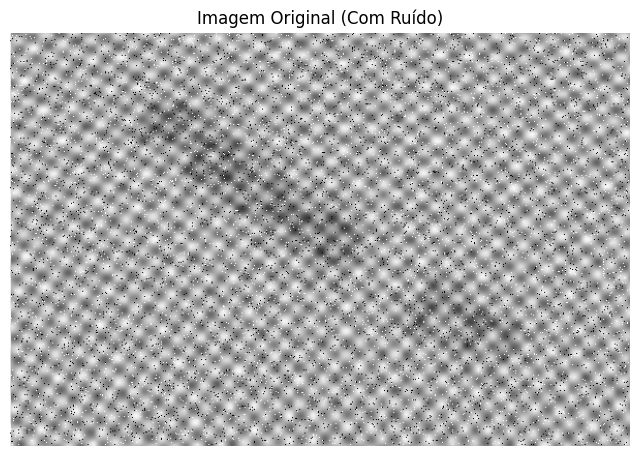

In [13]:
image_path = '../assets/Letters-noisy.png'
img_original = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img_original is None:
    print(f"Erro: Não foi possível carregar a imagem em '{image_path}'. Verifique o caminho.")
else:
    plt.imshow(img_original)
    plt.title('Imagem Original (Com Ruído)')
    plt.axis('off')
    plt.show()

### Passo 2: Análise no Domínio da Frequência

A Transformada de Fourier (DFT) permite-nos passar do domínio espacial (pixels) para o domínio da frequência. Nesta representação, o ruído periódico manifesta-se como pontos brilhantes e simétricos em relação ao centro do espectro.

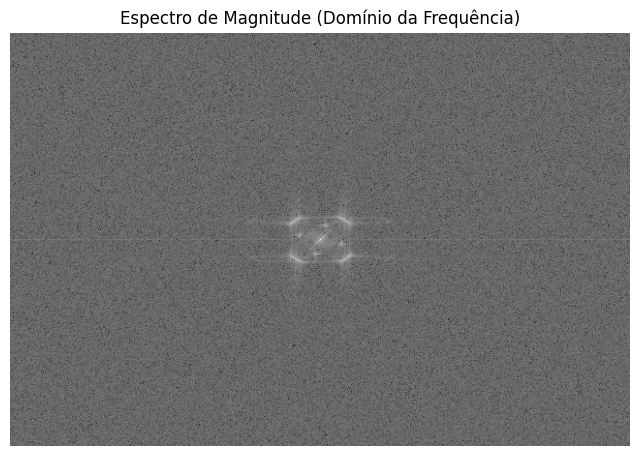

In [14]:
# Calcula a DFT. A imagem é convertida para float32.
dft = cv2.dft(np.float32(img_original), flags=cv2.DFT_COMPLEX_OUTPUT)

# Desloca o componente de frequência zero (DC) para o centro do espectro.
dft_shift = np.fft.fftshift(dft)

# Calcula o espectro de magnitude para visualização.
# A escala logarítmica (20*log) ajuda a realçar os picos, que de outra forma seriam pouco visíveis.
magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]) + 1)

plt.imshow(magnitude_spectrum)
plt.title('Espectro de Magnitude (Domínio da Frequência)')
plt.axis('off')
plt.show()

### Passo 3: Deteção Automática de Picos de Ruído (2 Passagens)

Para automatizar a remoção do ruído, precisamos de localizar estes picos brilhantes. Faremos isto em duas passagens para garantir que apanhamos tanto os picos óbvios como os mais subtis.

- **Passagem 1 (Picos Fortes):** Usamos um limiar (threshold) alto para isolar apenas os pontos mais brilhantes do espectro.
- **Passagem 2 (Picos Fracos):** Usamos um limiar mais baixo para encontrar picos secundários.

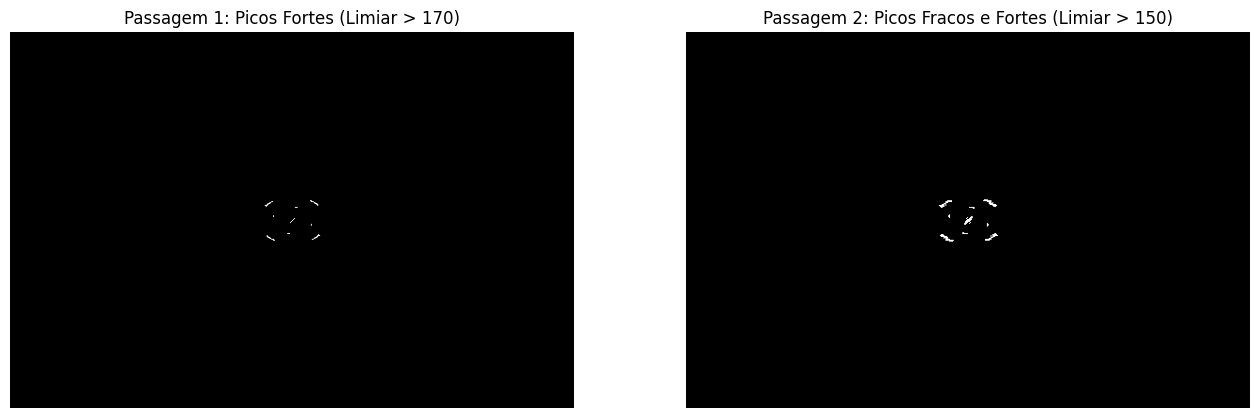

In [15]:
# Normaliza o espectro para o intervalo [0, 255] para que possamos usar funções do OpenCV.
norm_spectrum = cv2.normalize(magnitude_spectrum, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

# Limiares para as duas passagens.
THRESHOLD_STRONG = 170  # Valor alto para picos principais (X)
THRESHOLD_WEAK = 150    # Valor mais baixo para picos secundários (Y), onde Y < X

_, picos_fortes_img = cv2.threshold(norm_spectrum, THRESHOLD_STRONG, 255, cv2.THRESH_BINARY)
_, picos_fracos_img = cv2.threshold(norm_spectrum, THRESHOLD_WEAK, 255, cv2.THRESH_BINARY)

# Mostra os picos identificados em cada passagem
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

ax1.imshow(picos_fortes_img)
ax1.set_title(f'Passagem 1: Picos Fortes (Limiar > {THRESHOLD_STRONG})')
ax1.axis('off')

ax2.imshow(picos_fracos_img)
ax2.set_title(f'Passagem 2: Picos Fracos e Fortes (Limiar > {THRESHOLD_WEAK})')
ax2.axis('off')

plt.show()

### Passo 4: Criação do Filtro Notch Combinado

Agora, criamos uma máscara (um "filtro notch") para bloquear as frequências dos picos detetados. A máscara será uma imagem preta com círculos brancos, mas aqui vamos inverter a lógica: uma imagem branca onde colocamos círculos pretos (valor 0) para anular os picos.

- **Picos Fortes:** Serão bloqueados com um círculo de raio maior, pois correspondem a uma interferência mais forte.
- **Picos Fracos:** Serão bloqueados com um raio menor, para uma filtragem mais "cirúrgica" sem afetar frequências vizinhas importantes.

--- Criando Máscara (Passagem 1) ---
Pares de Filtros Notch Gaussianos aplicados (D0=6): 2

--- Atualizando Máscara (Passagem 2) ---
Pares de Filtros Notch Gaussianos aplicados (D0=3): 2


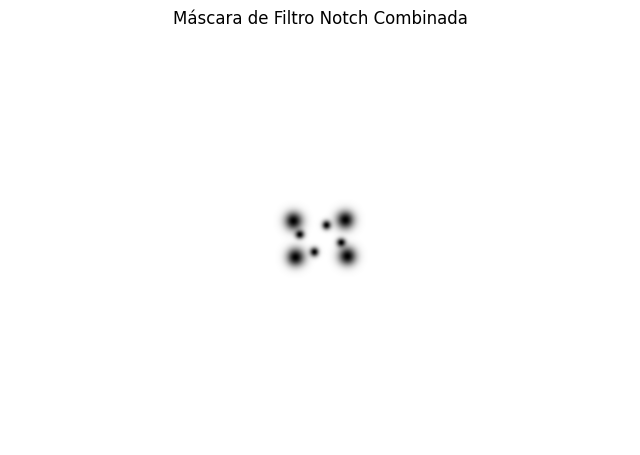

In [16]:
import cv2
import numpy as np

def criar_mascara_notch_gaussiana(shape, picos_img, raio, mascara_existente=None):
    """Cria ou atualiza uma máscara notch gaussiana a partir de uma imagem de picos."""
    # Para filtros gaussianos contínuos, é essencial usar float32 no intervalo [0.0, 1.0]
    if mascara_existente is None:
        mascara = np.ones(shape, dtype=np.float32)
    else:
        mascara = mascara_existente.copy()
        # Se a máscara anterior vier em uint8 (0-255), convertemos para float32 (0.0-1.0)
        if mascara.dtype == np.uint8:
            mascara = mascara.astype(np.float32) / 255.0
    
    # Encontra os contornos dos picos
    contours, _ = cv2.findContours(picos_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    crow, ccol = shape[0] // 2, shape[1] // 2
    min_dist_centro = 5 
    
    # Cria uma matriz de coordenadas (X, Y) para otimizar o cálculo matemático do Gaussiano
    Y, X = np.ogrid[:shape[0], :shape[1]]
    
    count = 0
    for cnt in contours:
        M = cv2.moments(cnt)
        if M["m00"] == 0:
            continue
            
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])

        dist_centro = np.sqrt((cX - ccol)**2 + (cY - crow)**2)
        
        # Verificamos se o centro deste pico ainda não foi atenuado (mascara perto de 1.0)
        if mascara[cY, cX] > 0.5 and dist_centro > min_dist_centro:
            
            # 1. Filtro Gaussiano para o pico detetado
            dist_sq_1 = (X - cX)**2 + (Y - cY)**2
            notch_1 = 1.0 - np.exp(-dist_sq_1 / (2 * (raio**2)))
            
            # 2. Filtro Gaussiano para o pico SIMÉTRICO (Crucial para não distorcer a imagem)
            sym_X = (2 * ccol) - cX
            sym_Y = (2 * crow) - cY
            dist_sq_2 = (X - sym_X)**2 + (Y - sym_Y)**2
            notch_2 = 1.0 - np.exp(-dist_sq_2 / (2 * (raio**2)))
            
            # Multiplicar a máscara atual pelos novos "buracos" gaussianos
            mascara = mascara * notch_1 * notch_2
            count += 1
            
    print(f"Pares de Filtros Notch Gaussianos aplicados (D0={raio}): {count}")
    return mascara

# Dimensões da imagem
rows, cols = img_original.shape
img_shape = (rows, cols)

# Raios dos filtros
RAIO_FORTE = 6 # Raio maior para picos fortes
RAIO_FRACO = 3  # Raio menor para picos fracos

print("--- Criando Máscara (Passagem 1) ---")
mascara_notch = criar_mascara_notch_gaussiana(img_shape, picos_fortes_img, RAIO_FORTE)

print("\n--- Atualizando Máscara (Passagem 2) ---")
mascara_notch = criar_mascara_notch_gaussiana(img_shape, picos_fracos_img, RAIO_FRACO, mascara_existente=mascara_notch)

# A máscara final precisa ter 2 canais para ser aplicada ao DFT (real e imaginário)
mascara_final = np.zeros((rows, cols, 2), dtype=np.float32)
mascara_final[:, :, 0] = mascara_notch
mascara_final[:, :, 1] = mascara_notch

plt.imshow(mascara_notch)
plt.title('Máscara de Filtro Notch Combinada')
plt.axis('off')
plt.show()

### Visualização da Máscara sobre o Espectro

Para ter uma ideia clara de quais frequências estão a ser bloqueadas, podemos sobrepor a máscara ao espectro de magnitude. As áreas a vermelho são as frequências que o nosso filtro está a remover.

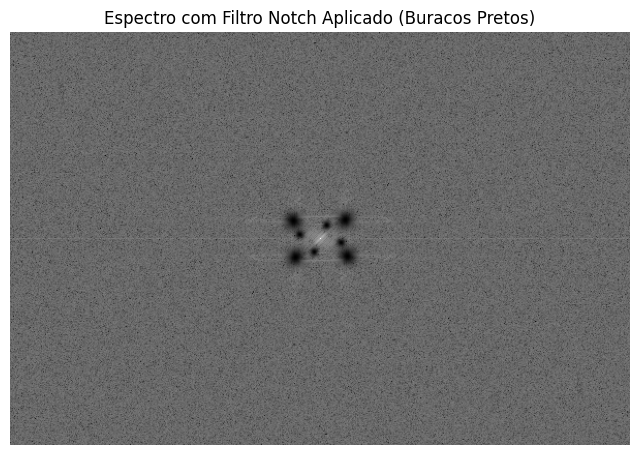

In [17]:
# Multiplica o espectro (0 a 255) pela máscara Gaussiana (0.0 a 1.0)
# As zonas bloqueadas (0.0) vão ficar pretas no espectro, de forma suave!
espectro_mascarado = norm_spectrum * mascara_notch

# Exibe a imagem em escala de cinza
plt.imshow(espectro_mascarado, cmap='gray')
plt.title('Espectro com Filtro Notch Aplicado (Buracos Pretos)')
plt.axis('off')
plt.savefig("../output/notchFilter.png", bbox_inches="tight")
plt.show()

### Passo 5: Filtragem de Ruído Periódico e Reconstrução

Multiplicamos o espectro de frequência pela máscara (onde os picos de ruído serão zerados) e, em seguida, aplicamos a Transformada Inversa de Fourier (IDFT) para voltar ao domínio espacial e ver a imagem limpa.

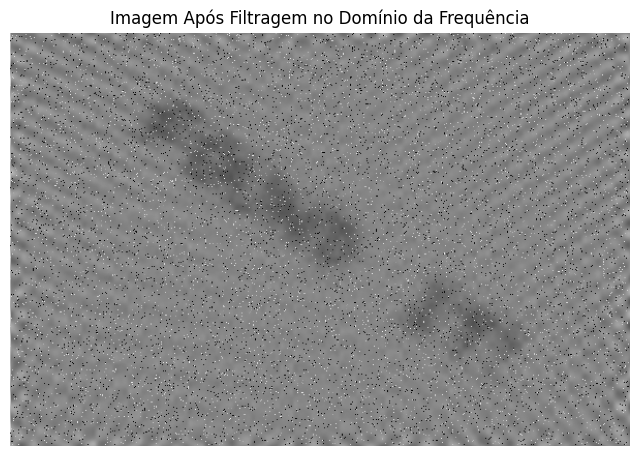

In [18]:
# Aplica a máscara ao espectro de frequência.
fshift_filtrado = dft_shift * mascara_final

# Desfaz o deslocamento do centro.
f_ishift = np.fft.ifftshift(fshift_filtrado)

# Calcula a Transformada Inversa para obter a imagem de volta.
img_filtrada_freq = cv2.idft(f_ishift)

# A imagem resultante é complexa. Pegamos a magnitude para ter uma imagem real.
img_filtrada_freq = cv2.magnitude(img_filtrada_freq[:, :, 0], img_filtrada_freq[:, :, 1])

# Normaliza a imagem para o intervalo [0, 255] para visualização.
cv2.normalize(img_filtrada_freq, img_filtrada_freq, 0, 255, cv2.NORM_MINMAX)
img_filtrada_freq = np.uint8(img_filtrada_freq)

plt.imshow(img_filtrada_freq)
plt.title('Imagem Após Filtragem no Domínio da Frequência')
plt.axis('off')
plt.show()

### Passo 6: Remoção de Ruído Sal e Pimenta

A imagem agora está livre do ruído periódico, mas ainda contém o ruído "sal e pimenta". O **filtro de mediana** é a ferramenta ideal para este problema. Ele substitui cada pixel pelo valor da mediana dos seus vizinhos, o que é muito eficaz para eliminar ruídos que são pontos extremos (muito brancos ou muito pretos).

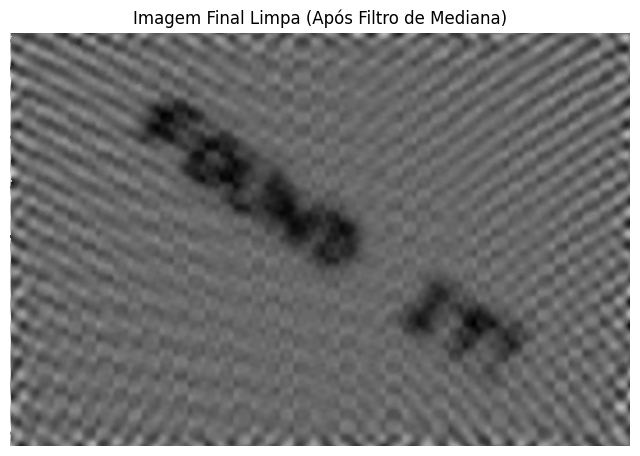

In [19]:
# Aplica um filtro de mediana com um kernel 3x3. 
# Este tamanho é geralmente suficiente para ruído sal e pimenta sem desfocar demais a imagem.
img_limpa = cv2.medianBlur(img_filtrada_freq, 3)

plt.imshow(img_limpa)
plt.title('Imagem Final Limpa (Após Filtro de Mediana)')
plt.axis('off')
plt.show()

### Passo 7: Análise do Histograma

O histograma mostra a distribuição das intensidades dos pixels. Ele ajuda-nos a entender se há uma separação clara entre o fundo (background) e os objetos de interesse (o texto), o que é útil para escolher uma boa estratégia de binarização.

C:\Users\paulo\AppData\Local\Temp\ipykernel_41164\1707350607.py:2: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img_limpa.ravel(), 256, [0, 256])


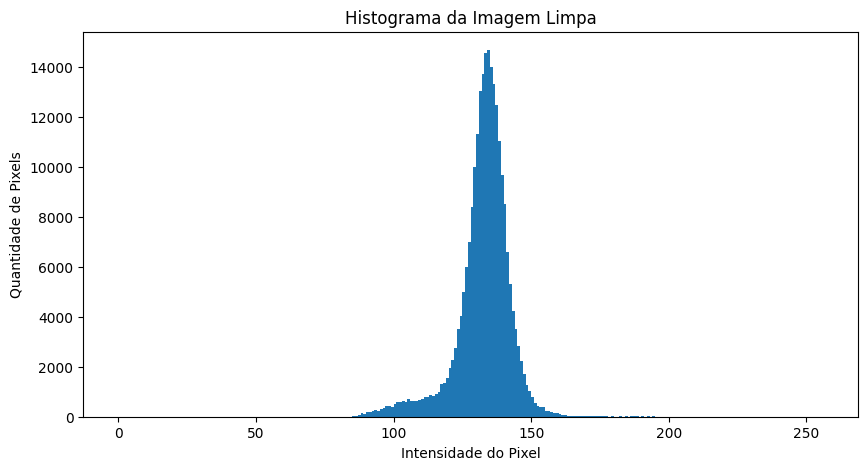

In [20]:
plt.figure(figsize=(10, 5))
plt.hist(img_limpa.ravel(), 256, [0, 256])
plt.title('Histograma da Imagem Limpa')
plt.xlabel('Intensidade do Pixel')
plt.ylabel('Quantidade de Pixels')
plt.show()

### Passo 8: Binarização Adaptativa

Binarizar é converter a imagem em preto e branco. Um limiar fixo (ex: tudo abaixo de 128 vira preto) não funcionaria bem aqui devido a variações de iluminação. A **binarização adaptativa** é a melhor solução, pois calcula um limiar diferente para cada pequena região da imagem, adaptando-se às condições locais.

Usamos `THRESH_BINARY_INV` porque o nosso texto é escuro e queremos que ele fique branco (valor 255) no resultado final, que é o formato esperado pela maioria dos algoritmos de contorno.

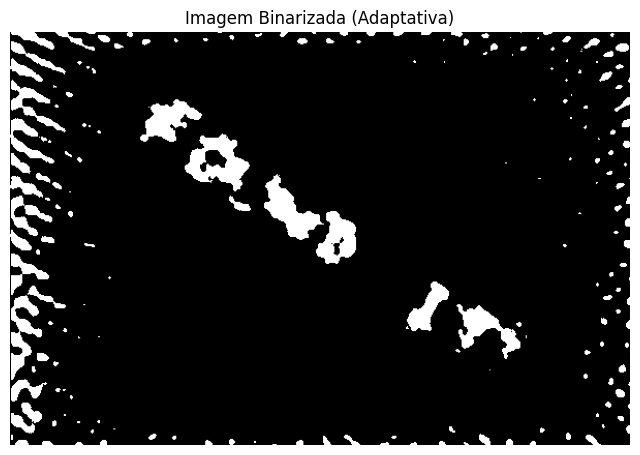

In [21]:
# blockSize: Tamanho da vizinhança para calcular o limiar (deve ser ímpar).
# C: Uma constante subtraída da média ou média ponderada. Ajuda a refinar o limiar.
img_binarizada = cv2.adaptiveThreshold(
    img_limpa, 
    255, 
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY_INV, 
    blockSize=221, # Um bloco maior pode ajudar com gradientes suaves
    C=15
)

plt.imshow(img_binarizada)
plt.title('Imagem Binarizada (Adaptativa)')
plt.axis('off')
plt.show()

### Passo 9: Deteção de Contornos (Canny)

Finalmente, aplicamos o detector de contornos de Canny. Ele é eficaz para encontrar as bordas das letras na imagem binarizada, dando-nos o resultado final limpo e segmentado.

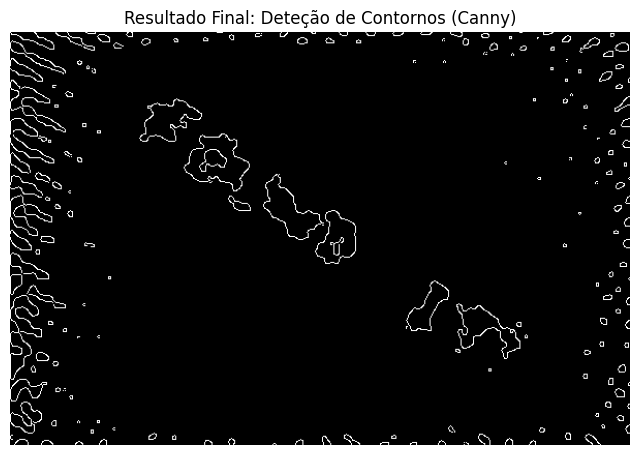

In [22]:
# O detector de Canny usa dois limiares (min e max) para detetar bordas fortes e fracas.
edges = cv2.Canny(img_binarizada, 100, 200)

plt.imshow(edges)
plt.title('Resultado Final: Deteção de Contornos (Canny)')
plt.axis('off')
plt.show()